**Eksik veri türleri ve tespiti**

* Analizin doğruluğunu etkileyen en yaygın problem - analizi bozar
* veri kalitesini ve güvenilirliği düşürür
* Model performansını azaltır
* Karar verme süreçlerinde hatalara sebep olabilir
****
**Eksik verinin oluşma nedenleri**

* Katılımcıların soruları atlaması (anket)
* Sensör veya sistem hataları
* Veri toplama sürecindeki eksiklikler
* Dosya aktarım hataları
* Bilinçli olarak paylaşılmayan bilgiler
****
**Eksik veri türleri**

* MCAR (missing completely at random): Eksiklik tamamen rastgele
* MAR (Missing at random): Eksiklik başka bir değişkene bağlıdır.
* MNAR (Missing not at Random): eksiklik kendi değişkeniyle ilgilidir.
> Türü belirlemek -> doğru yöntem
****
**Eksik veriyi tespit etme yöntemleri**

* Gözle kontrol - özetleme tabloları
* verideki boş hücre sayımı
* Eksik oranlarının hesaplanması
* Görselleştirme
* Eksik veri raporu oluşturma (Data quality report)
****
**Eksik veriyle ilgili karar süreci**
* Eksik veri miktarı analiz edilir
* Eksiklik rastgele mi
* Verinin önemi belirlenir
* Gerekirse gelişmiş yöntemler uygulanır


**Eksik veri doldurmanın amacı**
* Eksik değerleri koruyarak veri setini kullanılır hale getirmek
* Veri kaybını en aza indirmel
* Gerçek dağılıma en yakın değerlerle doldurmak
* Modelin öğrenme sürecini dengede tutmak


## Yöntemler


*Nasıl seçilir*
- Veri türü -> yöntem seçimini belirler
* eks,klik oranı yüksekse ileri seviye yöntem gerekir
* Doldurma sonrası veri dağılımı kontrol edilmeli

### Ortalama ile doldurma
* Sayısal ve sürekli değerler
* basit ve hızlı
* outlier dan etkilenir

### Median ile doldurma
* outlier dan etkilenmez
* Merkezi eğilimi korur
* Özellikle çarpık (skewed) dağılımlar için uygundur
* Sıralı (ordinal) değişkenlerde tercih edilir


### Mode ile doldurma
* Kategorik veriler
* En sık tekrar eden değerle
* Basit ama etkili
* Dağılımda tek kategori baskın hale gelir - veri çeşitliliği azalır

### **Gelişmiş Yöntemler**
* Basit doldurma yeterli olmayınca
* Veriler gerçek hayatta birbirine bağlı
* Gelişmiş yöntemler tahmine dayalı yaklaşım kullanır
* Gerçekçi ve dinamik değerler üretebilir
****
1. KNN ile
    * Eksik değeri tahmin ederken benzer gözlemi kullanır
    * En yakın k komşu
    * Hep en yakınları bulmaya çalışıyor *yavaş*
2. Regresyon ile
    * Regresyon modeli kurulur
    * Eksik sütun bağımlı değişken (y = 2x + 3k + 45)
    * Diğer sürunlar bağımsız değişken
    * Model bir kez kurulduğu için *hızlı*
****
Dikkat edilmesi gerekenler:
* Model doğruluğunu çapraz doğrulama ile test et
* Doldurma sonrası veri dağılımı kontrol (histogram - boxplot - countplot)
* overfitting riski
* Eksik verinin nedeni ne? !

# Missing value problem


## Eksik veri türleri ve tespiti (Housing dataset)
* Veri yükle
* Veri genel özet
* MV kontrol
* MV simüle et
* MV görselleştirme
* Eksiklik oranı analiz tablosu


In [3]:
# Gerekli kütüphaneler
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno # Eksik veri görselleştirme kütüphanesi


In [6]:
df = pd.read_csv("/content/housing.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [10]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [11]:
# Eksik değer kontrolü
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [16]:
missing_percent = df.isnull().mean() * 100 # Her sütundaki eksik değer yüzdesi
missing_percent

,0
CRIM,0.0
ZN,0.0
INDUS,0.0
CHAS,0.0
NOX,0.0
RM,0.0
AGE,0.0
DIS,0.0
RAD,0.0
TAX,0.0


In [19]:
# Eksik değerleri simüle

np.random.seed(42)

# age ve dis sütunlarına %10 oranında eksik değer ekle
for col in ["AGE", "DIS"]:
  df.loc[df.sample(frac = 0.1).index, col] = np.nan

In [20]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,51
DIS,51
RAD,0
TAX,0


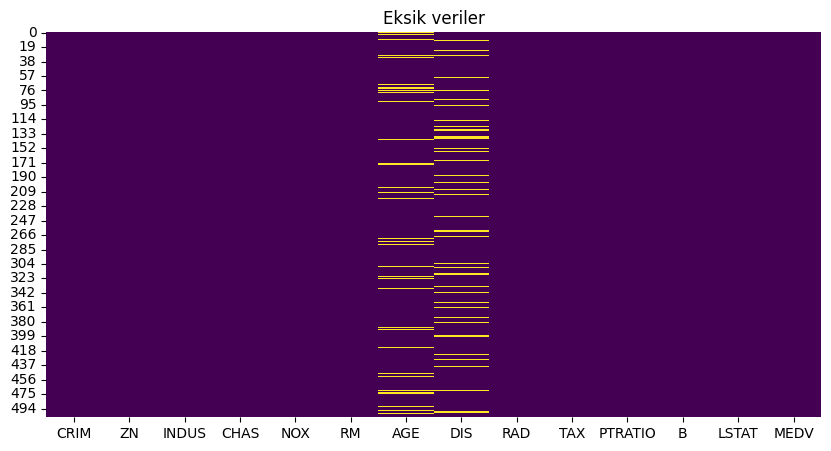

In [22]:
# Eksik değerlerin görselleştirilmesi

plt.figure(figsize= (10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Eksik veriler")
plt.show()

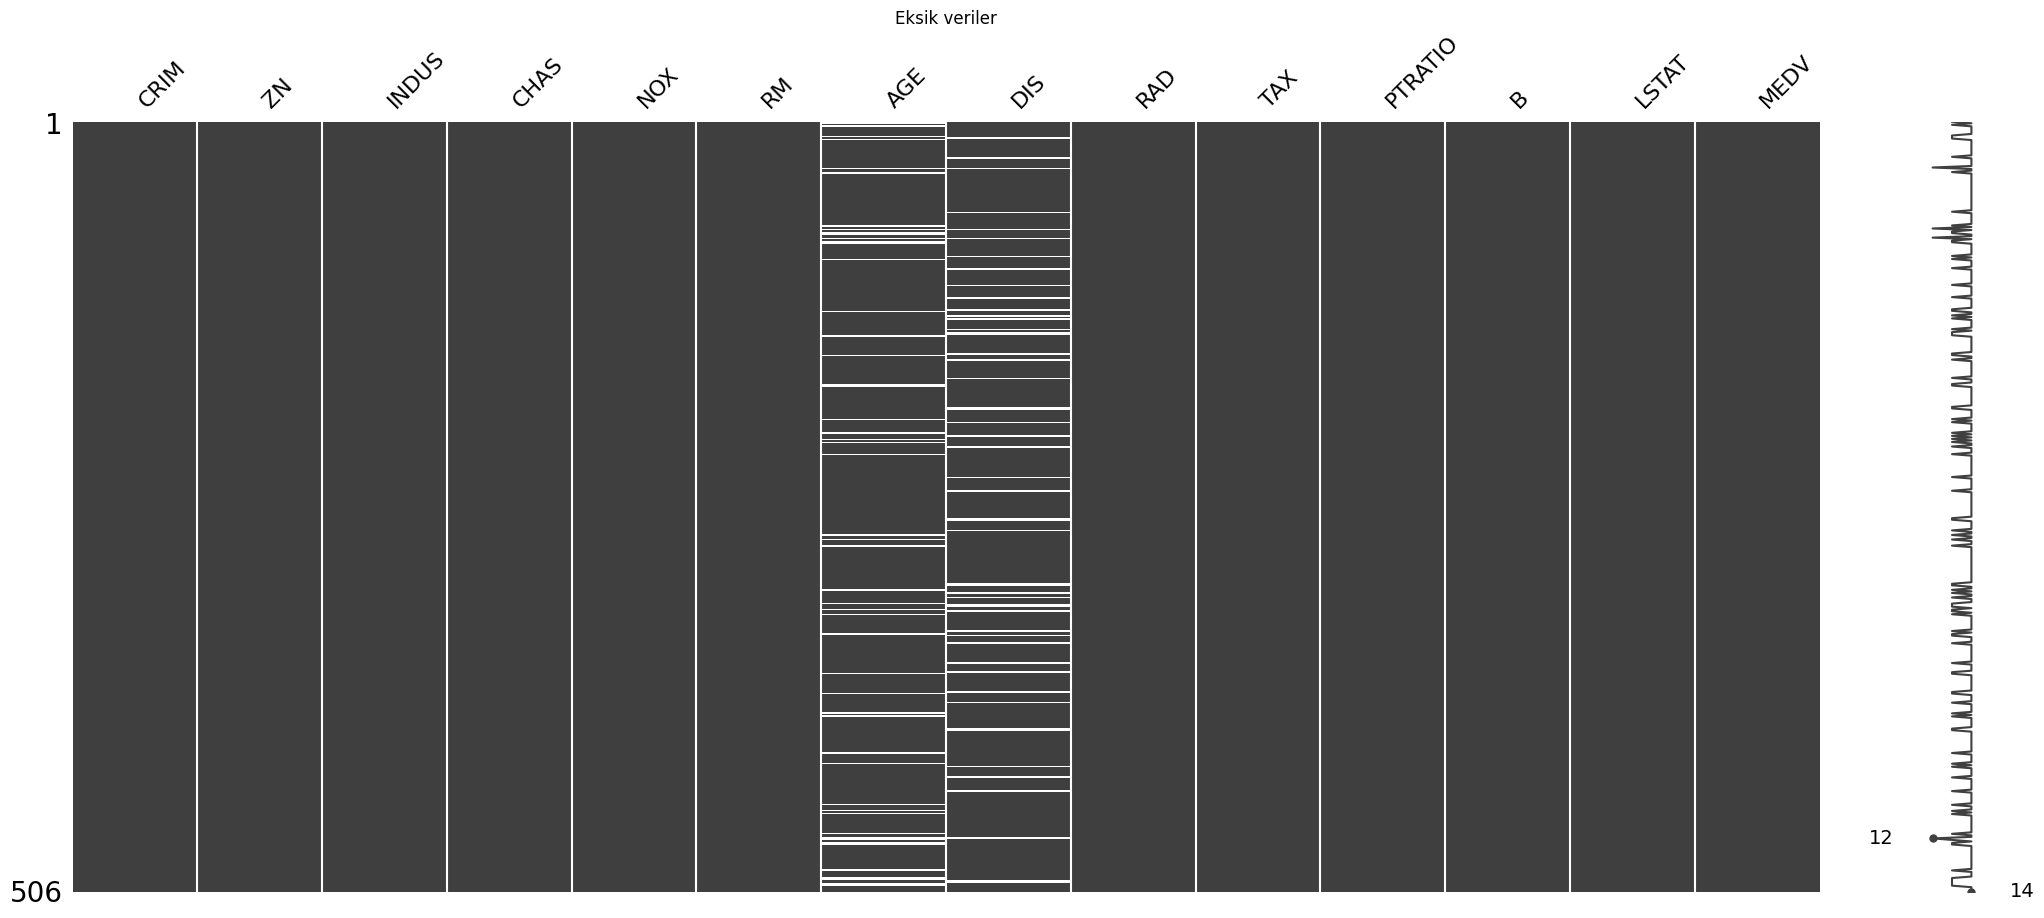

In [23]:
# alternatif missingno

msno.matrix(df)
plt.title("Eksik veriler")
plt.show()

In [29]:
# Eksiklik oranı analiz tablosu

missing_report = pd.DataFrame({
    "eksik sayı": df.isnull().sum(),
    "eksik oran": round(df.isnull().mean() * 100, 1)
})

print(missing_report.sort_values(by = "eksik oran", ascending = False))

         eksik sayı  eksik oran
DIS              51        10.1
AGE              51        10.1
INDUS             0         0.0
CHAS              0         0.0
CRIM              0         0.0
ZN                0         0.0
RM                0         0.0
NOX               0         0.0
RAD               0         0.0
TAX               0         0.0
PTRATIO           0         0.0
B                 0         0.0
LSTAT             0         0.0
MEDV              0         0.0


Bu aşamaya kadar:
 * Verideki eksik değerler bulundu
 * oranı hesaplandı
 * görsel olarak analiz edildi
 * Eksiklik türü -> tamamen rastgele

## Eksik veri doldurma
* ortalama
* median
* mode

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# housing csv okuma
df = pd.read_csv("/content/housing.csv")

In [34]:
# eksik veri simülasyonu
np.random.seed(42)

for col in ["AGE", "DIS"]:
  df.loc[df.sample(frac = 0.1).index, col] = np.nan
print(df.head())
print(df.isnull().sum())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575   NaN  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185   NaN  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  
CRIM        0
ZN          0
INDUS       0
CHAS        0
NOX         0
RM          0
AGE        51
DIS        51
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT       0
MEDV        0
dtype: int64


In [48]:
# ortalama ile doldurma
df_mean = df.copy()
mean_value = df_mean["AGE"].mean()

df_mean.fillna({"AGE" : mean_value}, inplace = True)
print(f"Age sütunu ortalama {mean_value:2f} ile dolduruldu")
print(df_mean["AGE"].isnull().sum(), "eksik değer kaldı.")

Age sütunu ortalama 68.252747 ile dolduruldu
0 eksik değer kaldı.


In [49]:
# Median ile doldurma

df_median = df.copy()
median_value = df_median["DIS"].median()

df_median.fillna({"DIS" : median_value}, inplace = True)

print(f"DIS sütunu median {median_value:2f} ile dolduruldu")
print(df_median["DIS"].isnull().sum(), "eksik değer kaldı.")

DIS sütunu median 3.215700 ile dolduruldu
0 eksik değer kaldı.


In [51]:
# Mode ile doldurma (Kategorik değer)
# eksik veri simülasyonu
np.random.seed(42)

for col in ["CHAS"]:
  df.loc[df.sample(frac = 0.1).index, col] = np.nan
print(df.head())
print(df.isnull().sum())


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   NaN  0.538  6.575   NaN  4.0900    1  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07   NaN  0.469  7.185   NaN  4.9671    2  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  CMAS  
0     15.3  396.90   4.98  24.0   NaN  
1     17.8  396.90   9.14  21.6   NaN  
2     17.8  392.83   4.03  34.7   NaN  
3     18.7  394.63   2.94  33.4   NaN  
4     18.7  396.90   5.33  36.2   NaN  
CRIM         0
ZN           0
INDUS        0
CHAS        51
NOX          0
RM           0
AGE         51
DIS         51
RAD          0
TAX          0
PTRATIO      0
B            0
LSTAT        0
MEDV         0
CMAS       506
dtype: int64


In [52]:
df_mode = df.copy()
mode_value = df_mode["CHAS"].mode()[0]

df_mode.fillna({"CHAS" : mode_value}, inplace = True)

print(f"CHAS sütunu mode {mode_value} ile dolduruldu")
print(df_mode["CHAS"].isnull().sum(), "eksik değer kaldı.")

CHAS sütunu mode 0.0 ile dolduruldu
0 eksik değer kaldı.


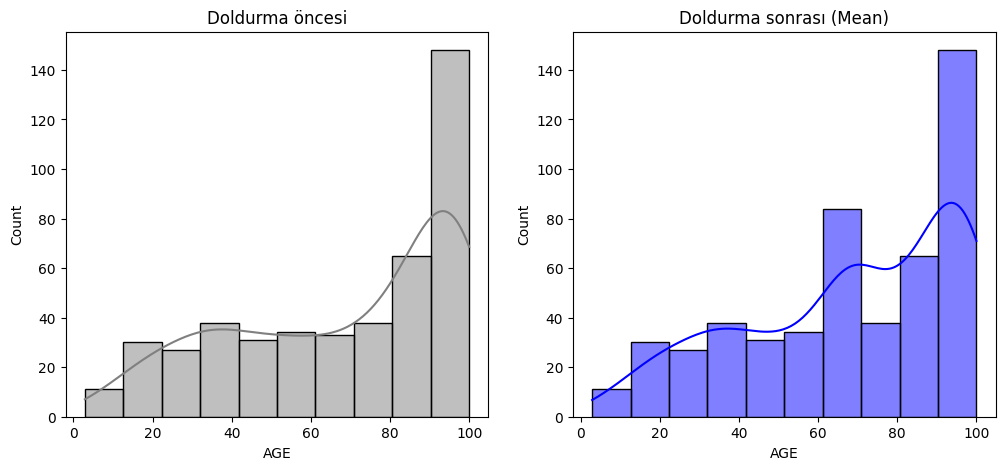

In [58]:
# Doldurma öncesi ve sonrası karşılaştırma

plt.figure(figsize = (12, 5))

plt.subplot(1,2,1) # 1 satır 2 sütun oluşsun 1'i çizelim
sns.histplot(df['AGE'], color = "gray", kde=True)
plt.title("Doldurma öncesi")

plt.subplot(1,2,2) # 2. için
sns.histplot(df_mean['AGE'], color = "blue", kde=True)
plt.title("Doldurma sonrası (Mean)")
plt.show()


68 de artış var belki median kullanılabilirdi

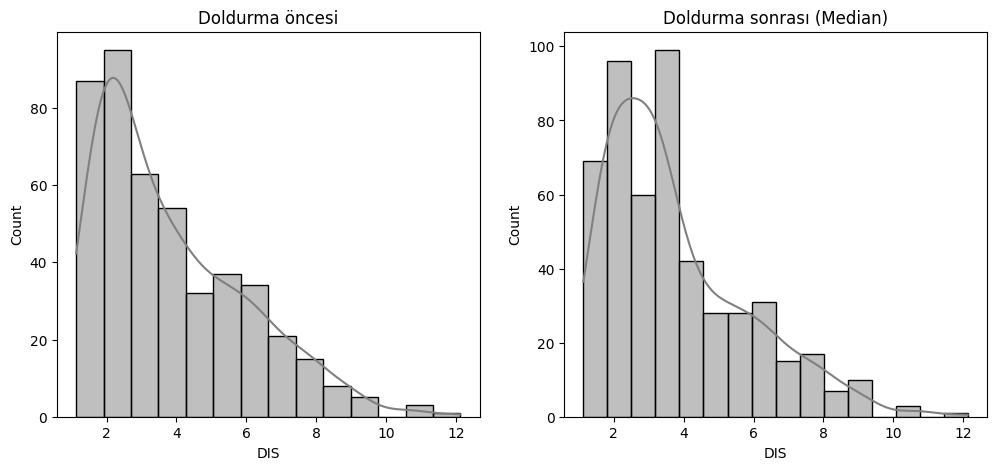

In [67]:
# Median için

plt.figure(figsize = (12, 5))

plt.subplot(1,2,1) # 1
sns.histplot(df['DIS'], color = "gray", kde = True)
plt.title("Doldurma öncesi")

plt.subplot(1,2,2) # 2
sns.histplot(df_median['DIS'], color = "gray", kde = True)
plt.title("Doldurma sonrası (Median)")
plt.show()

0-4 arasında dağılım yanlış olmuş. Ama genel dağılım hala iyi durumda

Bu aşamaya kadar:
 * ort ile doldurma
 * mode ile doldurma
 * median ile doldurma

## Gelişmiş yöntemler
* KNN ile mv doldurma
* Regresyon ile mv doldurma

In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [70]:
# veriyi yükle
df = pd.read_csv("/content/housing.csv")

np.random.seed(42)

for col in ["AGE", "DIS", "RM"]:
  df.loc[df.sample(frac = 0.1).index, col] = np.nan

df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,51
AGE,51
DIS,51
RAD,0
TAX,0


In [71]:
## KNN ile doldurma

df_knn = df.copy()

imputer = KNNImputer(n_neighbors = 3)
df_knn_imputed = imputer.fit_transform(df_knn)

# dönüşüm sonrası np array den pandas df e çevir

df_knn = pd.DataFrame(df_knn_imputed, columns = df_knn.columns)
df_knn.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [73]:
# Regresyon ile kayıp değer doldurma

df_reg = df.copy()

# eksik olmayan satırları train, eksik olanları predict olarak ayır
train_Data = df_reg[df_reg["AGE"].notnull()] # null olmayanlar
predict_Data = df_reg[df_reg["AGE"].isnull()] # null olanlar

train_Data = train_Data.fillna(train_Data.mean())
predict_Data = predict_Data.fillna(predict_Data.mean())

# bağımlı ve bağımsız değişkenleri ayır
x_train = train_Data.drop(columns = ["AGE"])
y_train = train_Data["AGE"]
x_pred = predict_Data.drop(columns = ["AGE"])

# Regresyon modeli oluştur
model = LinearRegression()
model.fit(x_train, y_train)

# tahmin
predicted_values = model.predict(x_pred)

# tahmin edilen değerleri yerine yaz
df_reg.loc[df_reg["AGE"].isnull(), "AGE"] = predicted_values
df_reg["AGE"].isnull().sum()

np.int64(0)